In [ ]:
import sys
sys.path.append('../')

import numpy as np
import math
import torch
from torch import nn
import matplotlib.pyplot as plt
import pandas as pd
from torch.utils.data import DataLoader
from src.mypackage.torch_dataset import EnergyDataset
from src.mypackage.trainer import Trainer

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        seq_len = x.size(1)
        x = x + self.pe[:, :seq_len]
        return x

class TimeSeriesTransformerModel(nn.Module):
    def __init__(self, input_size, output_channels, kernel_size, output_size, 
                 num_heads, dim_feedforward, num_layers, dropout):
        super().__init__()
        self.conv = nn.Conv1d(input_size, output_channels, kernel_size=kernel_size, 
                              padding=kernel_size//2)
        self.pe = PositionalEncoding(d_model=output_channels)
        self.dropout = nn.Dropout(dropout)
        self.transformer_encoder = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model=output_channels, nhead=num_heads, 
                                       dim_feedforward=dim_feedforward, 
                                       dropout=dropout, batch_first=True), 
                                       num_layers=num_layers)
        self.fc = nn.Linear(output_channels, output_size)
    
    def forward(self, x):
        x = self.conv(x.transpose(1, 2)).transpose(1, 2)
        x = self.pe(x)
        x = self.dropout(x)
        x = self.transformer_encoder(x)
        x = self.fc(x[:, -1, :])
        return x

In [3]:
# ========== データ読み込みとデータセット準備 ==========
df = pd.read_csv("../data/raw/PJME_hourly.csv")
print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

# ========== ハイパーパラメータ設定 ==========
SEQ_LEN = 168  # 1週間
PRED_LEN = 24  # 24時間先予測
SHIFT = 24  # 24時間ずつずらす
BATCH_SIZE = 32
NUM_EPOCHS = 50
LEARNING_RATE = 0.001
WEIGHT_DECAY = 1e-5
EARLY_STOPPING_PATIENCE = 10

# ========== データセット作成 ==========
train_dataset = EnergyDataset(df, seq_len=SEQ_LEN, shift=SHIFT, pred_len=PRED_LEN, mode="train")
test_dataset = EnergyDataset(df, seq_len=SEQ_LEN, shift=SHIFT, pred_len=PRED_LEN, mode="test")

# 訓練データを訓練/検証に分割
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_subset, val_subset = torch.utils.data.random_split(train_dataset, [train_size, val_size])

# DataLoader作成
train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train dataset size: {len(train_subset)}")
print(f"Val dataset size: {len(val_subset)}")
print(f"Test dataset size: {len(test_dataset)}")
print(f"Input features: {train_dataset[0][0].shape[1]}")


Dataset shape: (145366, 2)
Columns: ['Datetime', 'PJME_MW']
Train dataset size: 4523
Val dataset size: 1131
Test dataset size: 358
Input features: 19


In [13]:
# ========== モデル初期化 ==========
INPUT_SIZE = train_dataset[0][0].shape[1]
HIDDEN_SIZE = 128
NUM_LAYERS = 2
DROPOUT = 0.2
OUTPUT_SIZE = PRED_LEN

# Transformerモデルの初期化
model = TimeSeriesTransformerModel(
    input_size=INPUT_SIZE,
    output_channels=HIDDEN_SIZE,
    kernel_size=3,
    output_size=OUTPUT_SIZE,
    num_heads=4,
    dim_feedforward=256,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
)

print(f"Model summary:")
print(model)

# Model parameters count
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")


Model summary:
TimeSeriesTransformerModel(
  (conv): Conv1d(19, 128, kernel_size=(3,), stride=(1,), padding=(1,))
  (pe): PositionalEncoding()
  (dropout): Dropout(p=0.2, inplace=False)
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=256, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.2, inplace=False)
        (dropout2): Dropout(p=0.2, inplace=False)
      )
    )
  )
  (fc): Linear(in_features=128, out_features=24, bias=True)
)
Total parameters: 275,480
Trainable

In [14]:
# ========== Trainerの初期化と訓練 ==========
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

trainer = Trainer(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    device=device,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    early_stopping_patience=EARLY_STOPPING_PATIENCE,
    checkpoint_dir="../models/transformer_checkpoints"
)

# 訓練実行
print("\n========== Starting Training ==========")
history = trainer.train(num_epochs=NUM_EPOCHS, verbose=True)
print("\n========== Training Complete ==========")

# 訓練要約表示
summary = trainer.get_summary()
print("\nTraining Summary:")
for key, value in summary.items():
    print(f"  {key}: {value}")


Using device: cpu

========== Starting Training ==========
Validation loss decreased (inf --> 0.127461). Saving model...
Validation loss decreased (0.127461 --> 0.106148). Saving model...
Validation loss decreased (0.106148 --> 0.093833). Saving model...
EarlyStopping counter: 1 out of 10
Validation loss decreased (0.093833 --> 0.091652). Saving model...
Epoch [5/50] - Train Loss: 0.114358, Val Loss: 0.091652 - Train MAE: 0.254501, Val MAE: 0.226480
EarlyStopping counter: 1 out of 10
Validation loss decreased (0.091652 --> 0.091080). Saving model...
Validation loss decreased (0.091080 --> 0.089606). Saving model...
Validation loss decreased (0.089606 --> 0.084894). Saving model...
EarlyStopping counter: 1 out of 10
Epoch [10/50] - Train Loss: 0.095252, Val Loss: 0.092341 - Train MAE: 0.230617, Val MAE: 0.223052
Validation loss decreased (0.084894 --> 0.083396). Saving model...
EarlyStopping counter: 1 out of 10
EarlyStopping counter: 2 out of 10
Validation loss decreased (0.083396 --> 

In [15]:
# ========== テストデータで評価 ==========
test_loss, test_mae, test_rmse = trainer.test()
print("\nTest Metrics:")
print(f"  Test Loss (MSE): {test_loss:.6f}")
print(f"  Test MAE: {test_mae:.6f}")
print(f"  Test RMSE: {test_rmse:.6f}")

# チェックポイントとコンフィグの保存
trainer.save_checkpoint()
trainer.save_config()


Test Metrics:
  Test Loss (MSE): 0.107888
  Test MAE: 0.233781
  Test RMSE: 0.316225
Checkpoint saved to ..\models\transformer_checkpoints\model_20260510_174309.pt
Configuration saved to ..\models\transformer_checkpoints\training_config_20260510_174309.json


History plot saved to ../figures/transformer_training_history.png


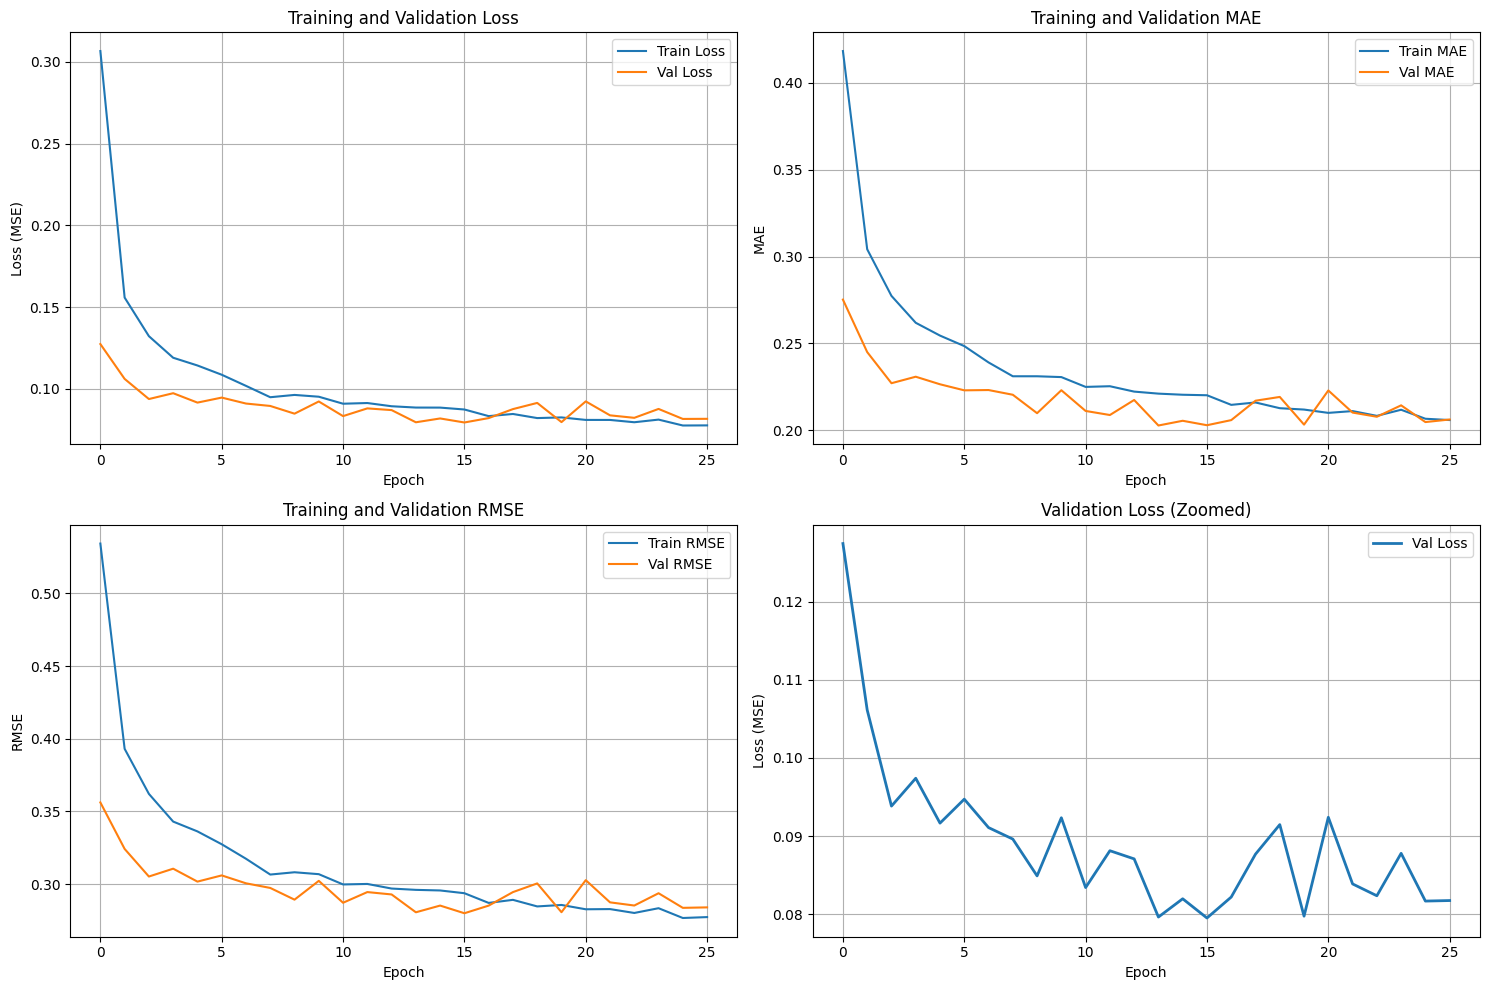


========== Predictions on Test Set ==========
Predictions shape: (358, 24)
Targets shape: (358, 24)


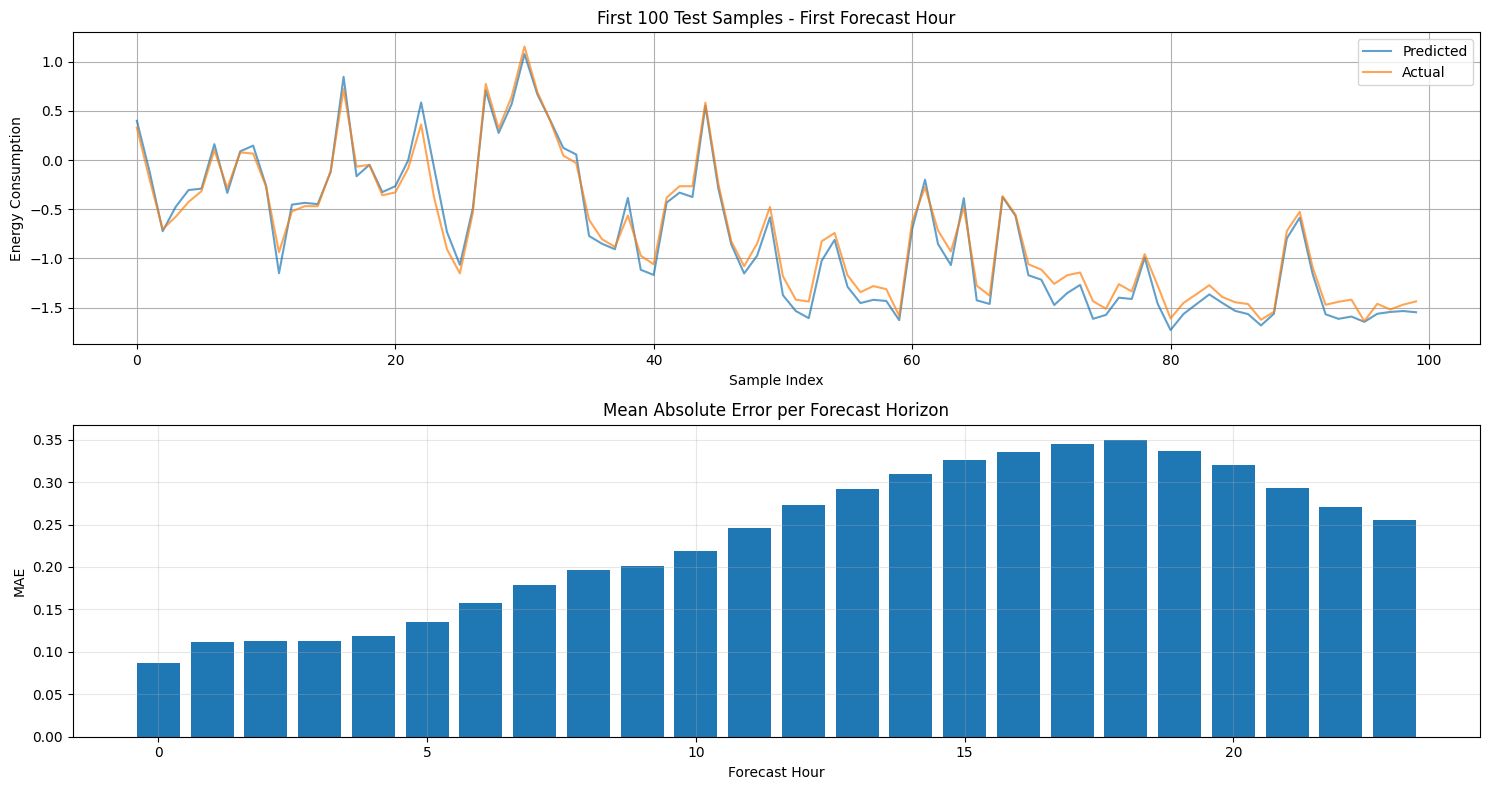

Figures saved to ../figures/


In [16]:
# ========== 訓練履歴の可視化 ==========
import os
fig, axes = trainer.plot_history(save_path="../figures/transformer_training_history.png")
plt.show()

# 予測結果の比較
print("\n========== Predictions on Test Set ==========")
all_predictions = []
all_targets = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        predictions = model(x).cpu().numpy()
        all_predictions.append(predictions)
        all_targets.append(y.numpy())

all_predictions = np.concatenate(all_predictions, axis=0)
all_targets = np.concatenate(all_targets, axis=0)

print(f"Predictions shape: {all_predictions.shape}")
print(f"Targets shape: {all_targets.shape}")

# 最初の100サンプルの予測と実際値をプロット
fig, axes = plt.subplots(2, 1, figsize=(15, 8))

# 最初の予測値
axes[0].plot(all_predictions[:100, 0], label='Predicted', alpha=0.7)
axes[0].plot(all_targets[:100, 0], label='Actual', alpha=0.7)
axes[0].set_title('First 100 Test Samples - First Forecast Hour')
axes[0].set_xlabel('Sample Index')
axes[0].set_ylabel('Energy Consumption')
axes[0].legend()
axes[0].grid(True)

# 平均予測誤差
mae_per_horizon = np.mean(np.abs(all_predictions - all_targets), axis=0)
axes[1].bar(range(len(mae_per_horizon)), mae_per_horizon)
axes[1].set_title('Mean Absolute Error per Forecast Horizon')
axes[1].set_xlabel('Forecast Hour')
axes[1].set_ylabel('MAE')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../figures/transformer_predictions.png", dpi=300, bbox_inches='tight')
plt.show()

print("Figures saved to ../figures/")


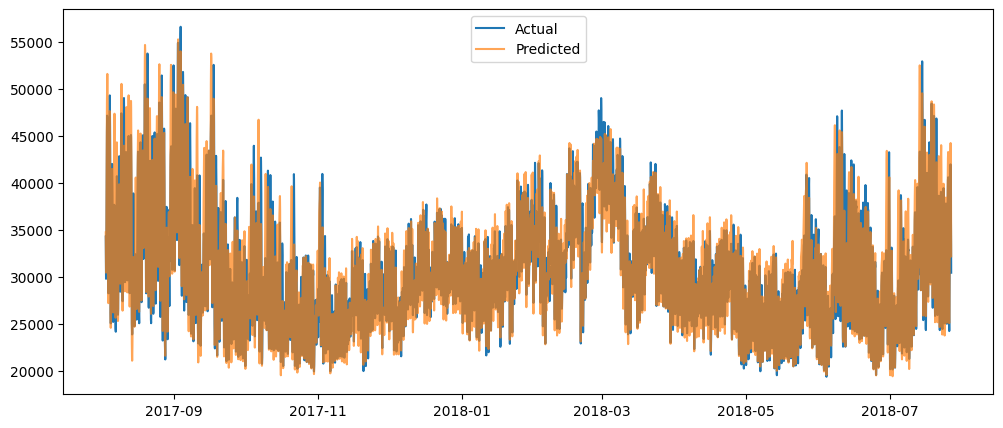

In [17]:
test_df = df.copy()
test_df["Datetime"] = pd.to_datetime(test_df["Datetime"])
test_df = test_df.sort_values("Datetime").reset_index(drop=True)
test_df = test_df[-365*24:]
plt.figure(figsize=(12, 5))
plt.plot(test_df["Datetime"][:len(all_targets.reshape(-1))], test_dataset.inverse_transform(all_targets.reshape(-1)), label='Actual')
plt.plot(test_df["Datetime"][:len(all_predictions.reshape(-1))], test_dataset.inverse_transform(all_predictions.reshape(-1)), label='Predicted', alpha=0.7)
plt.legend()
plt.show()